In [1]:
import zipfile
with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall(".")
print("✅ Extracted!")

✅ Extracted!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

In [3]:
# Fix TotalCharges column
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Encode target
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Drop customerID
df.drop(columns=["customerID"], inplace=True)

# Encode all text columns
df = pd.get_dummies(df)
print("✅ Cleaning done! Shape:", df.shape)

✅ Cleaning done! Shape: (7043, 46)


C:\Users\katta\AppData\Local\Temp\ipykernel_80128\4172383425.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print(f"✅ Model trained!")
print(f"ROC-AUC Score: {auc:.4f}")
print(classification_report(y_test, predictions))

✅ Model trained!
ROC-AUC Score: 0.8170
              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1035
           1       0.60      0.48      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



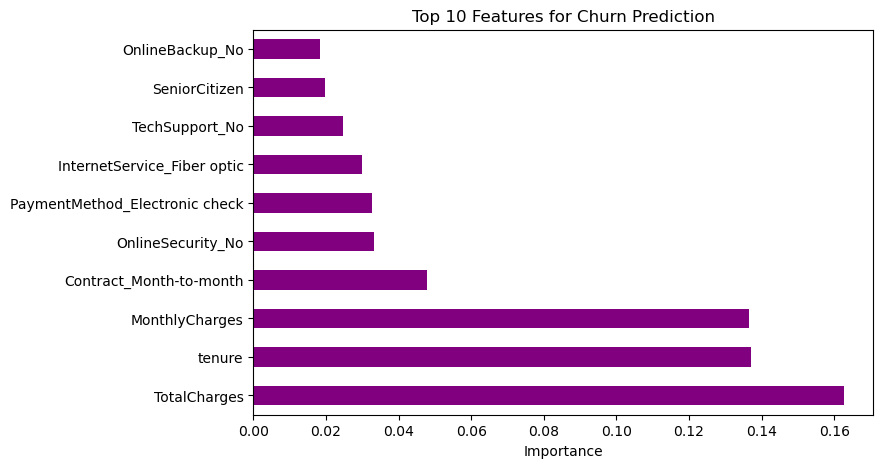

🎉 Churn Project Complete!


In [5]:
# Feature importance chart
feat_imp = pd.Series(model.feature_importances_,
                     index=X_train.columns)
feat_imp.sort_values(ascending=False).head(10).plot(
    kind="barh", color="purple", figsize=(8,5))
plt.title("Top 10 Features for Churn Prediction")
plt.xlabel("Importance")
plt.savefig("churn_result.png")
plt.show()
print("🎉 Churn Project Complete!")